In [2]:
from pathlib import Path
import pandas as pd

current = Path.cwd()
print("Current:", current)

sent_file = "5_year_ticker_headlines_with_finbert_rating_calculated.parquet"

for p in [current] + list(current.parents):
    candidate = p / "pipeline" / "output" / sent_file
    if candidate.exists():
        print("Found sentiment:", candidate)
        sent = pd.read_parquet(candidate)
        break
else:
    raise FileNotFoundError(f"Could not find {sent_file}")

print(sent.shape)
print(sent.head())
print(sent.columns)

Current: /Users/subhadeepdutta/Documents/GitHub/algorithmic-trading/notebooks/data_team/phase3/WIP
Found sentiment: /Users/subhadeepdutta/Documents/GitHub/algorithmic-trading/notebooks/data_team/pipeline/output/5_year_ticker_headlines_with_finbert_rating_calculated.parquet
(11110, 5)
                   sent_mean  sent_std  news_count  pct_strong_negative  \
Ticker Date                                                               
AAPL   2026-04-23   0.134550  0.395870          25                 4.00   
       2026-04-22   0.044053  0.367462          25                 8.00   
       2026-04-21   0.016289  0.450291          25                12.00   
       2026-04-20   0.215415  0.575118          25                12.00   
       2026-04-19   0.224013  0.556474          23                13.04   

                   sent_momentum  
Ticker Date                       
AAPL   2026-04-23       0.007686  
       2026-04-22      -0.120960  
       2026-04-21      -0.143801  
       2026-04

In [5]:
sent = sent.reset_index()

print(sent.columns)
print(sent.head())

Index(['Ticker', 'Date', 'sent_mean', 'sent_std', 'news_count',
       'pct_strong_negative', 'sent_momentum'],
      dtype='object')
  Ticker       Date  sent_mean  sent_std  news_count  pct_strong_negative  \
0   AAPL 2026-04-23   0.134550  0.395870          25                 4.00   
1   AAPL 2026-04-22   0.044053  0.367462          25                 8.00   
2   AAPL 2026-04-21   0.016289  0.450291          25                12.00   
3   AAPL 2026-04-20   0.215415  0.575118          25                12.00   
4   AAPL 2026-04-19   0.224013  0.556474          23                13.04   

   sent_momentum  
0       0.007686  
1      -0.120960  
2      -0.143801  
3       0.024563  
4       0.068227  


In [8]:
sent = sent.rename(columns={
    "Ticker": "ticker",
    "Date": "date"
})

In [9]:
import pandas as pd
import numpy as np

tech = pd.read_parquet("advanced_technical_features.parquet")






In [10]:
tech["date"] = pd.to_datetime(tech["date"]).dt.normalize()
sent["date"] = pd.to_datetime(sent["date"]).dt.normalize()

tech["ticker"] = tech["ticker"].astype(str).str.upper().str.strip()
sent["ticker"] = sent["ticker"].astype(str).str.upper().str.strip()

In [11]:
print("TECH")
print(tech[["date", "ticker"]].head())
print(tech.shape)

print("\nSENT")
print(sent[["date", "ticker"]].head())
print(sent.shape)

print("tech duplicates:", tech.duplicated(["date", "ticker"]).sum())
print("sent duplicates:", sent.duplicated(["date", "ticker"]).sum())

TECH
         date ticker
49 2020-03-26   AAPL
50 2020-03-29   AAPL
51 2020-03-30   AAPL
52 2020-03-31   AAPL
53 2020-04-01   AAPL
(64646, 16)

SENT
        date ticker
0 2026-04-23   AAPL
1 2026-04-22   AAPL
2 2026-04-21   AAPL
3 2026-04-20   AAPL
4 2026-04-19   AAPL
(11110, 7)
tech duplicates: 0
sent duplicates: 0


In [12]:
features = tech.merge(
    sent,
    on=["date", "ticker"],
    how="left"
)

print(features.shape)
print(features.head())
print(features.isna().sum())

(64646, 21)
        date ticker    return      ma_20      ma_50  ma20_ma50_ratio  \
0 2020-03-26   AAPL -0.041402  64.505183  71.267747         0.905110   
1 2020-03-29   AAPL  0.028538  64.103238  71.051111         0.902213   
2 2020-03-30   AAPL -0.002041  63.639799  70.846040         0.898283   
3 2020-03-31   AAPL -0.052617  63.245828  70.564883         0.896279   
4 2020-04-01   AAPL  0.016687  62.902357  70.309950         0.894644   

   distance_to_ma20  rolling_20d_return    rsi_14  macd_12_26_9  ...  \
0         -0.072006           -0.169160 -0.700259     -3.802070  ...   
1         -0.039538           -0.115489 -0.654483     -3.536766  ...   
2         -0.034518           -0.131078 -0.723253     -3.298625  ...   
3         -0.079622           -0.119224 -0.782335     -3.332355  ...   
4         -0.059154           -0.104002 -0.737182     -3.243321  ...   

     vol_20    atr_14  bollinger_pct_b  bollinger_width  volume_zscore_20  \
0  0.068909  5.368573         0.283828       

In [13]:
sent_cols = ["sent_mean", "sent_std", "news_count", "pct_strong_negative", "sent_momentum"]

matched = features[features[sent_cols].notna().all(axis=1)]

print("matched rows:", len(matched))
print("coverage %:", len(matched) / len(features) * 100)

print(matched[["date", "ticker"] + sent_cols].head(20))

matched rows: 5610
coverage %: 8.678031123348699
          date ticker  sent_mean  sent_std  news_count  pct_strong_negative  \
233 2021-04-29   AAPL  -0.030914  0.602011         6.0                16.67   
234 2021-05-03   AAPL  -0.099798  0.313423         3.0                 0.00   
235 2021-05-04   AAPL   0.072823  0.180174         6.0                 0.00   
236 2021-05-05   AAPL   0.278077  0.383101         5.0                 0.00   
237 2021-05-06   AAPL   0.548544  0.304371         3.0                 0.00   
241 2021-05-13   AAPL   0.353002  0.435754         5.0                 0.00   
250 2021-05-28   AAPL   0.376309  0.451769         3.0                 0.00   
265 2021-06-24   AAPL   0.043704  0.442672         3.0                 0.00   
281 2021-07-22   AAPL   0.205488  0.104077         2.0                 0.00   
290 2021-08-06   AAPL  -0.107826  0.283226         2.0                 0.00   
294 2021-08-12   AAPL   0.253138  0.300472         5.0                 0.00   
306

In [20]:
sent_cols = ["sent_mean", "sent_std", "news_count", "pct_strong_negative", "sent_momentum"]

features_sent_only = features.dropna(subset=sent_cols).copy()
features_sent_only = features_sent_only.reset_index(drop=True)

print(features_sent_only.shape)
print(features_sent_only["ticker"].nunique())
print(features_sent_only["date"].min(), features_sent_only["date"].max())
print(features_sent_only.duplicated(["date", "ticker"]).sum())
print(features_sent_only.isna().sum().sum())

features_sent_only.to_parquet("features_with_sentiment_only.parquet", index=False)

(5610, 21)
44
2021-04-28 00:00:00 2026-04-23 00:00:00
0
0


In [15]:
check = pd.read_parquet("features_with_sentiment_only.parquet")

print(check.shape)
print(check["ticker"].nunique())
print(check["date"].min(), check["date"].max())
print(check.duplicated(["date", "ticker"]).sum())
print(check.isna().sum().sum())
print(check.head())

(5610, 21)
44
2021-04-28 00:00:00 2026-04-23 00:00:00
0
0
        date ticker    return       ma_20       ma_50  ma20_ma50_ratio  \
0 2021-04-29   AAPL -0.015871  127.257395  124.550268         1.021735   
1 2021-05-03   AAPL  0.008216  127.800398  124.468063         1.026773   
2 2021-05-04   AAPL -0.033499  128.090162  124.296445         1.030522   
3 2021-05-05   AAPL  0.012802  128.418398  124.174306         1.034179   
4 2021-05-06   AAPL  0.005327  128.639063  124.077708         1.036762   

   distance_to_ma20  rolling_20d_return    rsi_14  macd_12_26_9  ...  \
0          0.006161            0.084564 -1.516698      2.047501  ...   
1          0.010117            0.091853 -1.316403      1.901692  ...   
2         -0.025929            0.048711 -0.722859      1.420805  ...   
3         -0.015981            0.054797 -0.586054      1.155273  ...   
4         -0.012436            0.035990 -0.640872      0.987770  ...   

     vol_20    atr_14  bollinger_pct_b  bollinger_width  volume_

In [21]:
# Use this if the saved file exists in this folder
final_df = pd.read_parquet("features_with_sentiment_only.parquet")

print(final_df.shape)
print(final_df.columns)
print(final_df.head())

(5610, 21)
Index(['date', 'ticker', 'return', 'ma_20', 'ma_50', 'ma20_ma50_ratio',
       'distance_to_ma20', 'rolling_20d_return', 'rsi_14', 'macd_12_26_9',
       'macd_histogram', 'vol_20', 'atr_14', 'bollinger_pct_b',
       'bollinger_width', 'volume_zscore_20', 'sent_mean', 'sent_std',
       'news_count', 'pct_strong_negative', 'sent_momentum'],
      dtype='object')
        date ticker    return       ma_20       ma_50  ma20_ma50_ratio  \
0 2021-04-29   AAPL -0.015871  127.257395  124.550268         1.021735   
1 2021-05-03   AAPL  0.008216  127.800398  124.468063         1.026773   
2 2021-05-04   AAPL -0.033499  128.090162  124.296445         1.030522   
3 2021-05-05   AAPL  0.012802  128.418398  124.174306         1.034179   
4 2021-05-06   AAPL  0.005327  128.639063  124.077708         1.036762   

   distance_to_ma20  rolling_20d_return    rsi_14  macd_12_26_9  ...  \
0          0.006161            0.084564 -1.516698      2.047501  ...   
1          0.010117            0.0

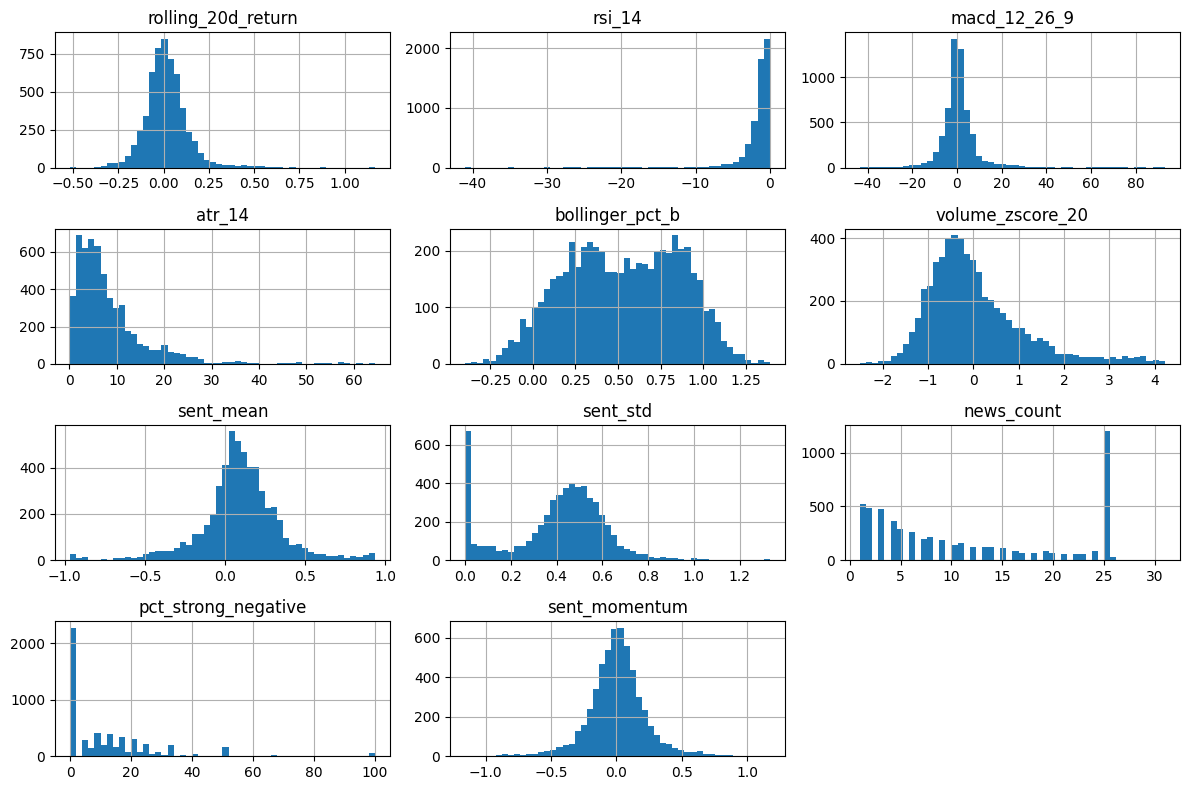

In [22]:
import matplotlib.pyplot as plt

cols = [
    "rolling_20d_return","rsi_14","macd_12_26_9",
    "atr_14","bollinger_pct_b","volume_zscore_20",
    "sent_mean","sent_std","news_count","pct_strong_negative","sent_momentum"
]

final_df[cols].hist(bins=50, figsize=(12,8))
plt.tight_layout()
plt.show()

In [26]:
sent_cols = ["sent_mean","sent_std","news_count","pct_strong_negative","sent_momentum"]


print(final_df[sent_cols].nunique())


print(final_df[sent_cols].std())

sent_mean              5573
sent_std               5037
news_count               29
pct_strong_negative     108
sent_momentum          5610
dtype: int64
sent_mean               0.253436
sent_std                0.218104
news_count              9.051020
pct_strong_negative    16.419462
sent_momentum           0.221067
dtype: float64


In [29]:
sent_cols = ["sent_mean", "sent_std", "news_count", "pct_strong_negative", "sent_momentum"]

features_full_neutral = features.copy()

features_full_neutral[sent_cols] = features_full_neutral[sent_cols].fillna({
    "sent_mean": 0,
    "sent_std": 0,
    "news_count": 0,
    "pct_strong_negative": 0,
    "sent_momentum": 0
})

features_full_neutral = features_full_neutral.reset_index(drop=True)

output_path = "/Users/subhadeepdutta/Documents/GitHub/algorithmic-trading/notebooks/data_team/pipeline/output/features_full_neutral_sentiment.parquet"

features_full_neutral.to_parquet(output_path, index=False)

print(features_full_neutral.shape)
print(features_full_neutral["ticker"].nunique())
print(features_full_neutral["date"].min(), features_full_neutral["date"].max())
print(features_full_neutral.duplicated(["date", "ticker"]).sum())
print(features_full_neutral.isna().sum().sum())

(64646, 21)
50
2020-03-26 00:00:00 2026-05-05 00:00:00
0
0


In [31]:
import pyarrow.parquet as pq
import pandas as pd

prices_path = "/Users/subhadeepdutta/Documents/GitHub/algorithmic-trading/notebooks/data_team/pipeline/output/clean_prices_50_assets.parquet"

table = pq.read_table(prices_path)
prices = table.to_pandas(ignore_metadata=True)

print(prices.shape)
print(prices.head())
print(prices.tail())
print(prices.columns[:20])

(1594, 301)
                     Date  ('Adj Close', 'AAPL')  ('Adj Close', 'AMD')  \
0 1970-01-01 00:26:17.923              72.400513             49.099998   
1 1970-01-01 00:26:18.009              71.696625             48.599998   
2 1970-01-01 00:26:18.268              72.267937             48.389999   
3 1970-01-01 00:26:18.355              71.928055             48.250000   
4 1970-01-01 00:26:18.441              73.085098             47.830002   

   ('Adj Close', 'AMZN')  ('Adj Close', 'ASML')  ('Adj Close', 'BABA')  \
0              94.900497             285.900818             208.714478   
1              93.748497             281.293610             206.083832   
2              95.143997             279.056122             205.741928   
3              95.343002             282.086700             206.682129   
4              94.598503             285.013458             207.033508   

   ('Adj Close', 'BAC')  ('Adj Close', 'BRK-B')  ('Adj Close', 'COP')  \
0             30.587555  

In [32]:
aapl_cols = [c for c in prices.columns if "AAPL" in str(c)]
print(aapl_cols)

cols = ["Date"] + aapl_cols
print(prices[cols].head(10))
print(prices[cols].tail(10))

["('Adj Close', 'AAPL')", "('Close', 'AAPL')", "('High', 'AAPL')", "('Low', 'AAPL')", "('Open', 'AAPL')", "('Volume', 'AAPL')"]
                     Date  ('Adj Close', 'AAPL')  ('Close', 'AAPL')  \
0 1970-01-01 00:26:17.923              72.400513          75.087502   
1 1970-01-01 00:26:18.009              71.696625          74.357498   
2 1970-01-01 00:26:18.268              72.267937          74.949997   
3 1970-01-01 00:26:18.355              71.928055          74.597504   
4 1970-01-01 00:26:18.441              73.085098          75.797501   
5 1970-01-01 00:26:18.528              74.637482          77.407501   
6 1970-01-01 00:26:18.614              74.806244          77.582497   
7 1970-01-01 00:26:18.873              76.404411          79.239998   
8 1970-01-01 00:26:18.960              75.372704          78.169998   
9 1970-01-01 00:26:19.046              75.049698          77.834999   

   ('High', 'AAPL')  ('Low', 'AAPL')  ('Open', 'AAPL')  ('Volume', 'AAPL')  
0         75.

In [34]:
import pandas as pd

tech_path = "advanced_technical_features.parquet"

tech = pd.read_parquet(tech_path)

print("tech shape:", tech.shape)
print("tickers:", tech["ticker"].nunique())
print("date range:", tech["date"].min(), tech["date"].max())
print("unique dates:", tech["date"].nunique())
print("rows per ticker:")
print(tech.groupby("ticker").size().describe())
print(tech.groupby("ticker").size().sort_values().head(10))
print(tech.groupby("ticker").size().sort_values().tail(10))

tech shape: (64646, 16)
tickers: 50
date range: 2020-03-26 00:00:00 2026-05-05 00:00:00
unique dates: 1293
rows per ticker:
count      50.000000
mean     1292.920000
std         0.444467
min      1290.000000
25%      1293.000000
50%      1293.000000
75%      1293.000000
max      1293.000000
dtype: float64
ticker
META     1290
BRK-B    1292
AAPL     1293
NOW      1293
NVDA     1293
ORCL     1293
PAA      1293
PDD      1293
PEP      1293
PLUG     1293
dtype: int64
ticker
INTC     1293
IWM      1293
JD       1293
JPM      1293
KO       1293
LVMUY    1293
MA       1293
MCD      1293
NFLX     1293
XOM      1293
dtype: int64
